# Descriptive Pre-Trend Check: AI Exposure and Wages (2001–2024)

This notebook provides a **descriptive pre-trend check** for the TWFE analysis. It estimates a year-specific cross-sectional slope of `ai_exposure` on `log_wage` across 2001–2024 using a pooled OLS model without individual fixed effects.

**Purpose and scope:**
The check asks whether occupations with higher AI exposure already commanded a wage premium before 2020. A pre-existing and stable cross-sectional relationship would suggest the pooled model captures occupational sorting (skill-level selection) rather than a post-2020 AI wage shock. A slope that accelerates specifically after 2020 would be more consistent with a structural break driven by AI adoption.

**Note on interpretation:** This is *not* a formal parallel trends test in the TWFE sense (which would require lead interaction terms within a within-person estimator). Because `ai_exposure` is a time-invariant occupation-level measure in this study, the standard event-study pre-trend design cannot be directly applied. This descriptive check — comparing cross-sectional slopes over time — is the appropriate alternative given the data structure.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('ggplot')

In [2]:
project_root = Path.cwd()
if project_root.name == 'output':
    project_root = project_root.parent

panel_path = project_root / 'data' / 'clean' / '06_hilda_person_wave_panel.csv'
aioe_path = project_root / 'data' / 'clean' / '01_aioe_by_anzsco.csv'
coef_out = project_root / 'output' / 'pretrend_ai_exposure_coefficients.csv'
summary_out = project_root / 'output' / 'pretrend_ai_exposure_summary.txt'

raw = pd.read_csv(panel_path)
aioe = pd.read_csv(aioe_path)

print('Panel rows:', len(raw))
print('Panel years:', sorted(raw['year'].dropna().astype(int).unique())[:5], '...', sorted(raw['year'].dropna().astype(int).unique())[-5:])
print('AI exposure rows:', len(aioe))

Panel rows: 500490
Panel years: [np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005)] ... [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
AI exposure rows: 1068


In [5]:
def normalize_occ_code(value, width: int):
    if pd.isna(value):
        return pd.NA
    text = str(value).strip().replace('.0', '')
    if text == '' or text.startswith('-') or not text.isdigit():
        return pd.NA
    return text.zfill(width)

def build_aioe_2digit(aioe_df: pd.DataFrame) -> pd.DataFrame:
    out = aioe_df.copy()
    out['anzsco_code'] = out['anzsco_code'].map(lambda x: normalize_occ_code(x, 6))
    out = out.dropna(subset=['anzsco_code', 'aioe_mean']).copy()
    out['anzsco2'] = out['anzsco_code'].str[:2]
    return (
        out.groupby('anzsco2', as_index=False)
        .agg(ai_exposure=('aioe_mean', 'mean'))
        .sort_values('anzsco2')
    )

def build_harmonized_pay(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    for col in ['wscmg', 'wscmga']:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors='coerce')
            out.loc[out[col] < 0, col] = pd.NA
    out['pay'] = pd.NA
    for col in ['wscmg', 'wscmga']:
        if col not in out.columns:
            continue
        mask = out['pay'].isna() & out[col].notna() & (out[col] > 0)
        out.loc[mask, 'pay'] = out.loc[mask, col]
    out['pay'] = pd.to_numeric(out['pay'], errors='coerce')
    return out

aioe2 = build_aioe_2digit(aioe)
df = raw.copy()
df['xwaveid'] = df['xwaveid'].astype(str).str.strip()
df['jbmo62'] = df['jbmo62'].map(lambda x: normalize_occ_code(x, 2))
df = build_harmonized_pay(df)
df['year'] = pd.to_numeric(df['year'], errors='coerce')
df = df.dropna(subset=['xwaveid', 'jbmo62', 'pay', 'year']).copy()
df = df[df['pay'] > 0].copy()
df = df[df['year'].between(2001, 2024)].copy()
df['year'] = df['year'].astype(int)
df['log_wage'] = np.log(df['pay'].astype(float))
df = df.merge(aioe2, left_on='jbmo62', right_on='anzsco2', how='left')

print('Analysis rows:', len(df))
print('Unique people:', df['xwaveid'].nunique())
print('Year span:', df['year'].min(), 'to', df['year'].max())
print('AI exposure coverage:', f"{df['ai_exposure'].notna().mean():.1%}")

Analysis rows: 194371
Unique people: 27009
Year span: 2001 to 2024
AI exposure coverage: 99.6%


In [8]:
# Year-specific slope model: each year gets its own intercept and AI-exposure slope.
est = df.dropna(subset=['xwaveid', 'year', 'log_wage', 'ai_exposure']).copy()
pretrend_model = smf.ols('log_wage ~ 0 + C(year) + ai_exposure:C(year)', data=est).fit(cov_type='cluster', cov_kwds={'groups': est['xwaveid']})

slope_terms = [f'ai_exposure:C(year)[{yr}]' for yr in sorted(est['year'].unique())]
slope_table = pd.DataFrame({
    'coef': pretrend_model.params.reindex(slope_terms),
    'std_err': pretrend_model.bse.reindex(slope_terms),
    'p_value': pretrend_model.pvalues.reindex(slope_terms),
    'ci_low': pretrend_model.conf_int().reindex(slope_terms)[0],
    'ci_high': pretrend_model.conf_int().reindex(slope_terms)[1],
}).round(6)
slope_table.index = sorted(est['year'].unique())

slope_table.to_csv(coef_out)

with summary_out.open('w', encoding='utf-8') as f:
    f.write('Pre-trend check for AI exposure and wages\n')
    f.write(f'Observations: {len(est):,}\n')
    f.write(f'Individuals: {est["xwaveid"].nunique():,}\n')
    f.write(f'Year span: {est["year"].min()} to {est["year"].max()}\n\n')
    f.write('Year-specific AI exposure slopes:\n')
    f.write(slope_table.to_string())
    f.write('\n\nFull model summary:\n')
    f.write(str(pretrend_model.summary()))

pretrend_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:               log_wage   R-squared:                       0.114
Model:                            OLS   Adj. R-squared:                  0.114
Method:                 Least Squares   F-statistic:                       nan
Date:                Tue, 28 Apr 2026   Prob (F-statistic):                nan
Time:                        09:20:40   Log-Likelihood:            -2.4040e+05
No. Observations:              193546   AIC:                         4.809e+05
Df Residuals:                  193498   BIC:                         4.814e+05
Df Model:                          47                                         
Covariance Type:              cluster                                         
=============================================================================================
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
C(year)[2001]                 6.2231      0.011    568.116      0.000       6.202       6.245
C(year)[2002]                 6.2376      0.011    558.922      0.000       6.216       6.259
C(year)[2003]                 6.2710      0.011    547.544      0.000       6.249       6.293
C(year)[2004]                 6.3202      0.011    550.595      0.000       6.298       6.343
C(year)[2005]                 6.3542      0.012    549.101      0.000       6.332       6.377
C(year)[2006]                 6.4013      0.011    566.893      0.000       6.379       6.423
C(year)[2007]                 6.4764      0.011    585.058      0.000       6.455       6.498
C(year)[2008]                 6.5299      0.011    572.156      0.000       6.508       6.552
C(year)[2009]                 6.5601      0.011    586.227      0.000       6.538       6.582
C(year)[2010]                 6.6048      0.011    598.080      0.000       6.583       6.626
C(year)[2011]                 6.6516      0.010    684.263      0.000       6.633       6.671
C(year)[2012]                 6.6832      0.010    680.268      0.000       6.664       6.702
C(year)[2013]                 6.6923      0.010    668.789      0.000       6.673       6.712
C(year)[2014]                 6.7091      0.010    688.597      0.000       6.690       6.728
C(year)[2015]                 6.7434      0.010    709.762      0.000       6.725       6.762
C(year)[2016]                 6.7747      0.009    720.998      0.000       6.756       6.793
C(year)[2017]                 6.8086      0.009    741.145      0.000       6.791       6.827
C(year)[2018]                 6.8407      0.009    749.161      0.000       6.823       6.859
C(year)[2019]                 6.8866      0.009    747.110      0.000       6.868       6.905
C(year)[2020]                 6.9364      0.009    767.554      0.000       6.919       6.954
C(year)[2021]                 6.9718      0.009    771.925      0.000       6.954       6.990
C(year)[2022]                 7.0036      0.009    769.506      0.000       6.986       7.021
C(year)[2023]                 7.0515      0.009    747.531      0.000       7.033       7.070
C(year)[2024]                 7.1088      0.009    786.383      0.000       7.091       7.126
ai_exposure:C(year)[2001]     0.5623      0.041     13.814      0.000       0.483       0.642
ai_exposure:C(year)[2002]     0.5905      0.041     14.294      0.000       0.509       0.671
ai_exposure:C(year)[2003]     0.6102      0.043     14.198      0.000       0.526       0.694
ai_exposure:C(year)[2004]     0.4890      0.042     11.548      0.000       0.406       0.572
ai_exposure:C(year)[2005]     0.5617      0.042     13.227      0.000       0.478       0.645
ai_exposure:C(year)[2006]     0.5618      0.043     13.109      0.000      

Average slope before 2020: 0.5922
Average slope 2020-2024: 0.6621
Linear pre-2020 trend per year: 0.006443


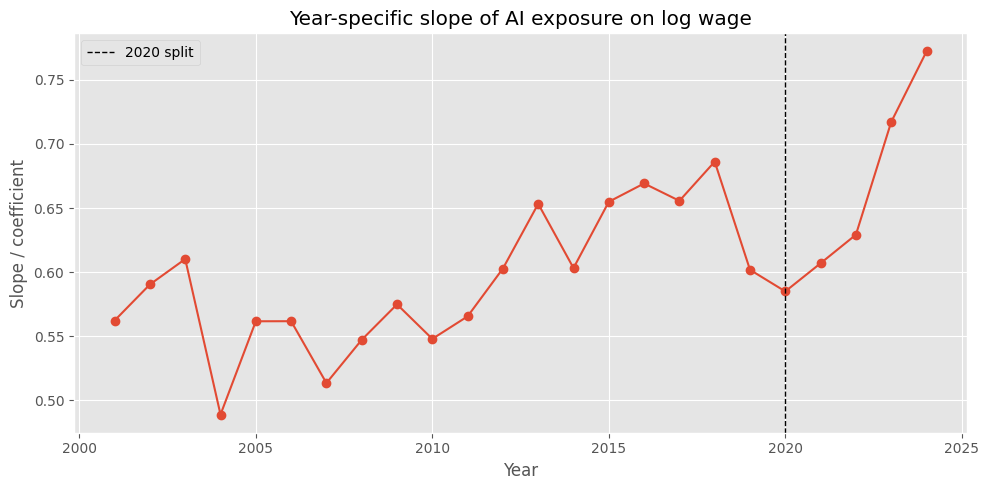

,coef,std_err,p_value,ci_low,ci_high
2001,0.5623,0.0407,0.0000,0.4825,0.6421
2002,0.5905,0.0413,0.0000,0.5095,0.6714
2003,0.6102,0.0430,0.0000,0.5260,0.6945
2004,0.4890,0.0423,0.0000,0.4060,0.5720
2005,0.5617,0.0425,0.0000,0.4785,0.6450
2006,0.5618,0.0429,0.0000,0.4778,0.6458
2007,0.5136,0.0420,0.0000,0.4313,0.5958
2008,0.5473,0.0424,0.0000,0.4641,0.6304
2009,0.5749,0.0413,0.0000,0.4940,0.6559
2010,0.5480,0.0403,0.0000,0.4690,0.6270


In [9]:
pre = slope_table.loc[slope_table.index < 2020].copy()
post = slope_table.loc[slope_table.index >= 2020].copy()

pre_mean = pre['coef'].mean()
post_mean = post['coef'].mean()
pre_trend = np.polyfit(pre.index.astype(float), pre['coef'].astype(float), 1)[0] if len(pre) >= 2 else np.nan

print('Average slope before 2020:', round(pre_mean, 4))
print('Average slope 2020-2024:', round(post_mean, 4))
print('Linear pre-2020 trend per year:', round(pre_trend, 6))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(slope_table.index, slope_table['coef'], marker='o')
ax.axvline(2020, color='black', linestyle='--', linewidth=1, label='2020 split')
ax.set_title('Year-specific slope of AI exposure on log wage')
ax.set_xlabel('Year')
ax.set_ylabel('Slope / coefficient')
ax.legend()
plt.tight_layout()
plt.show()

slope_table

## Pre-Trend Conclusion

The pre-trend check suggests that the positive association between AI exposure and wages was **already present before 2020**.

- The average slope before 2020 is about **0.592**, while the average slope in 2020-2024 rises to about **0.662**.
- The pre-2020 slope also shows a **mild upward trend** over time, with an estimated year-by-year increase of about **0.0064**.
- This means the 2021 result in the simpler models is not necessarily a pure new AI shock; part of it may reflect an existing upward wage trajectory among more AI-exposed occupations.
- Economically, the evidence is more consistent with **AI-exposed occupations already being on a higher-growth path**, rather than wages jumping only after 2020.
- So the safest interpretation is: **AI exposure and wage growth are positively correlated, but the post-2020 rise is layered on top of a pre-existing trend**.

For the final report, this should be presented as a robustness check that weakens a strict causal reading of the 2021 effect.